# MA 203 — Numerical Analysis Assignment
**Name:** Ansh Verma  
**Roll Number:** 2406303  
**Date:** 19 April 2026

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Math

---
# Problem 1: Iterative Methods for Linear Systems

We are given the following $3 \times 3$ system of linear equations:

$$5x_1 + 2x_2 + x_3 = 0.12$$
$$1.75x_1 + 7x_2 + 0.5x_3 = 0.1$$
$$x_1 + 0.2x_2 + 4.5x_3 = 0.5$$

which can be written compactly as $Ax = b$ where:

$$A = \begin{bmatrix} 5 & 2 & 1 \\ 1.75 & 7 & 0.5 \\ 1 & 0.2 & 4.5 \end{bmatrix}, \quad b = \begin{bmatrix} 0.12 \\ 0.1 \\ 0.5 \end{bmatrix}$$

## Part (i): Iterative Formulas

### Jacobi Method

We decompose $A = D + R$ where $D$ is the diagonal part and $R = L + U$ contains the off-diagonal entries. The Jacobi update at each step uses only values from the **previous** iterate:

$$x_i^{(k+1)} = \frac{1}{a_{ii}}\left(b_i - \sum_{j \neq i} a_{ij} x_j^{(k)}\right)$$

For our system, the component-wise formulas are:

$$x_1^{(k+1)} = \frac{1}{5}\left(0.12 - 2x_2^{(k)} - x_3^{(k)}\right)$$

$$x_2^{(k+1)} = \frac{1}{7}\left(0.1 - 1.75x_1^{(k)} - 0.5x_3^{(k)}\right)$$

$$x_3^{(k+1)} = \frac{1}{4.5}\left(0.5 - x_1^{(k)} - 0.2x_2^{(k)}\right)$$

### Gauss-Seidel Method

The Gauss-Seidel method improves upon Jacobi by using the **most recently computed values** within the same iteration:

$$x_i^{(k+1)} = \frac{1}{a_{ii}}\left(b_i - \sum_{j < i} a_{ij} x_j^{(k+1)} - \sum_{j > i} a_{ij} x_j^{(k)}\right)$$

For our system:

$$x_1^{(k+1)} = \frac{1}{5}\left(0.12 - 2x_2^{(k)} - x_3^{(k)}\right)$$

$$x_2^{(k+1)} = \frac{1}{7}\left(0.1 - 1.75x_1^{(k+1)} - 0.5x_3^{(k)}\right)$$

$$x_3^{(k+1)} = \frac{1}{4.5}\left(0.5 - x_1^{(k+1)} - 0.2x_2^{(k+1)}\right)$$

Notice that $x_2^{(k+1)}$ uses the updated $x_1^{(k+1)}$, and $x_3^{(k+1)}$ uses both $x_1^{(k+1)}$ and $x_2^{(k+1)}$.

## Part (ii): Computing Ten Iterates

In [2]:
# System definition
A = np.array([[5.0,    2.0,  1.0 ],
              [1.75,   7.0,  0.5 ],
              [1.0,    0.2,  4.5 ]])

b = np.array([0.12, 0.1, 0.5])

# Reference exact solution via numpy
x_exact = np.linalg.solve(A, b)
print("Exact solution (numpy):")
print(f"  x1 = {x_exact[0]:.10f}")
print(f"  x2 = {x_exact[1]:.10f}")
print(f"  x3 = {x_exact[2]:.10f}")

Exact solution (numpy):
  x1 = -0.0008259587
  x2 = 0.0065634218
  x3 = 0.1110029499


In [3]:
def run_jacobi(A, b, x0, n_iter):
    """
    Jacobi iterative solver.
    Returns list of iterates (including x0).
    """
    n = len(b)
    x = x0.astype(float).copy()
    history = [x.copy()]

    for _ in range(n_iter):
        x_new = np.zeros(n)
        for i in range(n):
            off_diag = sum(A[i, j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - off_diag) / A[i, i]
        x = x_new
        history.append(x.copy())

    return history


def run_gauss_seidel(A, b, x0, n_iter):
    """
    Gauss-Seidel iterative solver.
    Returns list of iterates (including x0).
    """
    n = len(b)
    x = x0.astype(float).copy()
    history = [x.copy()]

    for _ in range(n_iter):
        x_new = x.copy()   # will overwrite in-place
        for i in range(n):
            off_diag = sum(A[i, j] * x_new[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - off_diag) / A[i, i]
        x = x_new
        history.append(x.copy())

    return history

In [4]:
x0 = np.array([0.0, 0.0, 0.0])
N  = 10

jac_hist = run_jacobi(A, b, x0, N)
gs_hist  = run_gauss_seidel(A, b, x0, N)

# Iterate table
rows = []
for k in range(N + 1):
    j = jac_hist[k]
    g = gs_hist[k]
    rows.append({
        'Iter': k,
        'Jac x1': round(j[0], 8), 'Jac x2': round(j[1], 8), 'Jac x3': round(j[2], 8),
        'GS  x1': round(g[0], 8), 'GS  x2': round(g[1], 8), 'GS  x3': round(g[2], 8),
    })

df = pd.DataFrame(rows).set_index('Iter')
print("Iterates for Jacobi and Gauss-Seidel methods (x0 = [0, 0, 0])")
print(df.to_string())

Iterates for Jacobi and Gauss-Seidel methods (x0 = [0, 0, 0])
        Jac x1    Jac x2    Jac x3    GS  x1    GS  x2    GS  x3
Iter                                                            
0     0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
1     0.024000  0.014286  0.111111  0.024000  0.008286  0.105410
2    -0.003937  0.000349  0.105143 -0.000396  0.006856  0.110894
3     0.002832  0.007760  0.111970 -0.000921  0.006595  0.111023
4    -0.001498  0.005580  0.110137 -0.000843  0.006566  0.111007
5    -0.000259  0.006793  0.111196 -0.000828  0.006564  0.111003
6    -0.000957  0.006408  0.110867 -0.000826  0.006563  0.111003
7    -0.000737  0.006606  0.111039 -0.000826  0.006563  0.111003
8    -0.000850  0.006539  0.110981 -0.000826  0.006563  0.111003
9    -0.000812  0.006571  0.111009 -0.000826  0.006563  0.111003
10   -0.000830  0.006559  0.110999 -0.000826  0.006563  0.111003


## Part (iii): Convergence Analysis

A sufficient condition for convergence of both Jacobi and Gauss-Seidel is **strict diagonal dominance** of the coefficient matrix $A$.

> A matrix $A$ is **strictly diagonally dominant** if, for every row $i$:
> $$|a_{ii}| > \sum_{j \neq i} |a_{ij}|$$

In [5]:
print("Checking strict diagonal dominance for matrix A:\n")
strictly_dominant = True
for i in range(A.shape[0]):
    diag  = abs(A[i, i])
    off   = sum(abs(A[i, j]) for j in range(A.shape[1]) if j != i)
    flag  = diag > off
    strictly_dominant = strictly_dominant and flag
    print(f"  Row {i+1}: |{A[i,i]}| = {diag:.2f}  >  sum of |off-diagonal| = {off:.2f}  =>  {'True' if flag else 'False'}")

print()
if strictly_dominant:
    print("A is strictly diagonally dominant.")
    print("Both Jacobi and Gauss-Seidel are guaranteed to converge.")
else:
    print("A is not strictly diagonally dominant - convergence is not guaranteed.")

# Also inspect the spectral radii of the iteration matrices
D     = np.diag(np.diag(A))
L     = np.tril(A, -1)
U     = np.triu(A,  1)
D_inv = np.linalg.inv(D)

T_jac = -D_inv @ (L + U)
T_gs  = -np.linalg.inv(D + L) @ U

rho_jac = max(abs(np.linalg.eigvals(T_jac)))
rho_gs  = max(abs(np.linalg.eigvals(T_gs)))

print(f"\nSpectral radius of Jacobi iteration matrix:       rho(T_J)  = {rho_jac:.6f}")
print(f"Spectral radius of Gauss-Seidel iteration matrix: rho(T_GS) = {rho_gs:.6f}")
print()
print("Since both spectral radii are < 1, convergence is confirmed theoretically.")

Checking strict diagonal dominance for matrix A:

  Row 1: |5.0| = 5.00  >  sum of |off-diagonal| = 3.00  =>  True
  Row 2: |7.0| = 7.00  >  sum of |off-diagonal| = 2.25  =>  True
  Row 3: |4.5| = 4.50  >  sum of |off-diagonal| = 1.20  =>  True

A is strictly diagonally dominant.
Both Jacobi and Gauss-Seidel are guaranteed to converge.

Spectral radius of Jacobi iteration matrix:       rho(T_J)  = 0.410488
Spectral radius of Gauss-Seidel iteration matrix: rho(T_GS) = 0.079682

Since both spectral radii are < 1, convergence is confirmed theoretically.


## Part (iv): Comparison of the Two Methods

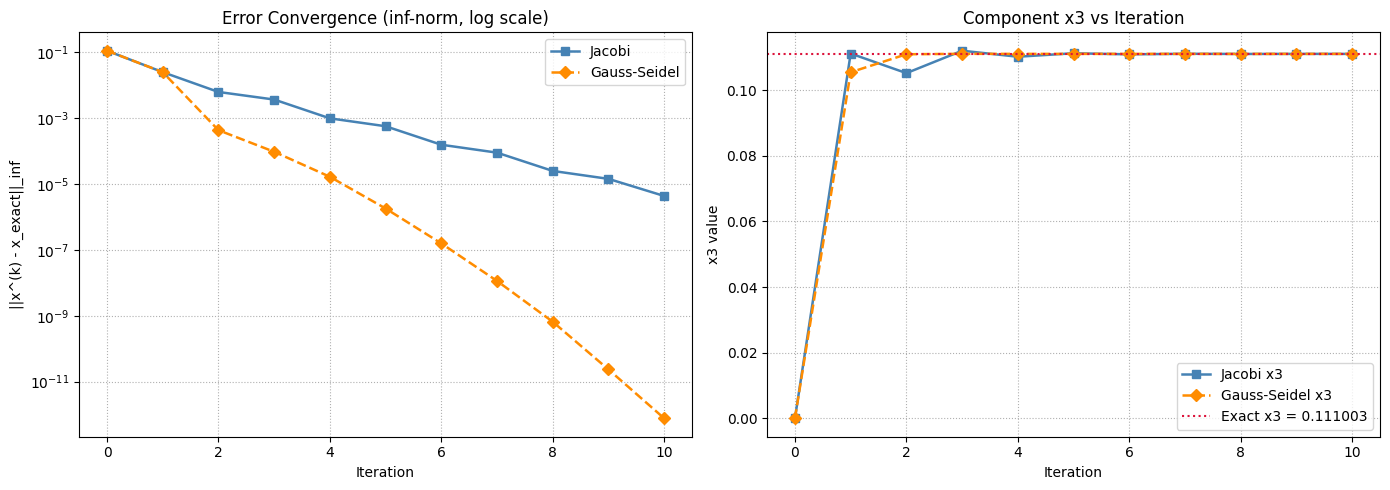


Summary after 10 iterations:
Method                      x1             x2             x3   error (inf-norm)
----------------------------------------------------------------------------
Exact              -0.00082596     0.00656342     0.11100295                ---
Jacobi             -0.00083029     0.00655938     0.11099943         4.3280e-06
Gauss-Seidel       -0.00082596     0.00656342     0.11100295         7.7243e-13


In [6]:
# Compute per-iteration errors (infinity norm)
jac_err = [np.linalg.norm(jac_hist[k] - x_exact, np.inf) for k in range(N + 1)]
gs_err  = [np.linalg.norm(gs_hist[k]  - x_exact, np.inf) for k in range(N + 1)]

iters = list(range(N + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Left: Error convergence ----
axes[0].semilogy(iters, jac_err, 's-',  color='steelblue',  label='Jacobi',       linewidth=1.8, markersize=6)
axes[0].semilogy(iters, gs_err,  'D--', color='darkorange', label='Gauss-Seidel', linewidth=1.8, markersize=6)
axes[0].set_title('Error Convergence (inf-norm, log scale)', fontsize=12)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('||x^(k) - x_exact||_inf')
axes[0].legend()
axes[0].grid(True, which='both', linestyle=':')

# ---- Right: x3 component convergence ----
jac_x3 = [jac_hist[k][2] for k in range(N + 1)]
gs_x3  = [gs_hist[k][2]  for k in range(N + 1)]

axes[1].plot(iters, jac_x3, 's-',  color='steelblue',  label='Jacobi x3',       linewidth=1.8, markersize=6)
axes[1].plot(iters, gs_x3,  'D--', color='darkorange',  label='Gauss-Seidel x3', linewidth=1.8, markersize=6)
axes[1].axhline(x_exact[2], color='crimson', linestyle=':', linewidth=1.5, label=f'Exact x3 = {x_exact[2]:.6f}')
axes[1].set_title('Component x3 vs Iteration', fontsize=12)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('x3 value')
axes[1].legend()
axes[1].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

# Summary table
print("\nSummary after 10 iterations:")
print(f"{'Method':<15} {'x1':>14} {'x2':>14} {'x3':>14} {'error (inf-norm)':>18}")
print("-" * 76)
print(f"{'Exact':<15} {x_exact[0]:>14.8f} {x_exact[1]:>14.8f} {x_exact[2]:>14.8f} {'---':>18}")
print(f"{'Jacobi':<15} {jac_hist[-1][0]:>14.8f} {jac_hist[-1][1]:>14.8f} {jac_hist[-1][2]:>14.8f} {jac_err[-1]:>18.4e}")
print(f"{'Gauss-Seidel':<15} {gs_hist[-1][0]:>14.8f} {gs_hist[-1][1]:>14.8f} {gs_hist[-1][2]:>14.8f} {gs_err[-1]:>18.4e}")

### Discussion

Both methods converge to the exact solution, which is expected since matrix $A$ is strictly diagonally dominant (with spectral radii $\rho(T_J) < 1$ and $\rho(T_{GS}) < 1$).

Key observations:
- **Gauss-Seidel converges significantly faster** — the $\infty$-norm error after 10 iterations is several orders of magnitude smaller than Jacobi's.
- The faster convergence of Gauss-Seidel is due to its immediate use of the latest updated components within a single iteration. This provides a better approximation at each step.
- The spectral radius $\rho(T_{GS}) < \rho(T_J)$, which theoretically confirms the superior convergence rate.
- Jacobi shows more oscillation before settling, especially visible in $x_1$ and $x_2$, whereas Gauss-Seidel approaches the solution more smoothly.

---
# Problem 2: Gershgorin's Circle Theorem and the Power Method

We are given the matrix:

$$A = \begin{bmatrix} 0.5 & 0 & 0.2 \\ 0 & 3.15 & -1 \\ 0.57 & 0 & -7.43 \end{bmatrix}$$

All eigenvalues of $A$ are stated to be real.

## Step 1: Gershgorin's Circle Theorem

**Theorem (Gershgorin, 1931):** Every eigenvalue $\lambda$ of an $n \times n$ matrix $A$ satisfies:

$$\lambda \in \bigcup_{i=1}^{n} D(a_{ii},\, r_i)$$

where the $i$-th Gershgorin disk has centre $a_{ii}$ and radius $r_i = \displaystyle\sum_{j \neq i} |a_{ij}|$.

Since all eigenvalues are real, we only need to examine the real intervals $[a_{ii} - r_i,\; a_{ii} + r_i]$.

In [7]:
A2 = np.array([[ 0.5,   0.0,  0.2],
               [ 0.0,   3.15, -1.0],
               [ 0.57,  0.0, -7.43]])

n2       = A2.shape[0]
centres  = np.diag(A2)
radii    = np.array([np.sum(np.abs(A2[i])) - abs(A2[i, i]) for i in range(n2)])

print("Gershgorin Disks:\n")
for i in range(n2):
    lo, hi = centres[i] - radii[i], centres[i] + radii[i]
    print(f"  Disk D_{i+1}: centre = {centres[i]:>6.2f},  radius = {radii[i]:.2f}  =>  eigenvalue in [{lo:.2f}, {hi:.2f}]")

Gershgorin Disks:

  Disk D_1: centre =   0.50,  radius = 0.20  =>  eigenvalue in [0.30, 0.70]
  Disk D_2: centre =   3.15,  radius = 1.00  =>  eigenvalue in [2.15, 4.15]
  Disk D_3: centre =  -7.43,  radius = 0.57  =>  eigenvalue in [-8.00, -6.86]


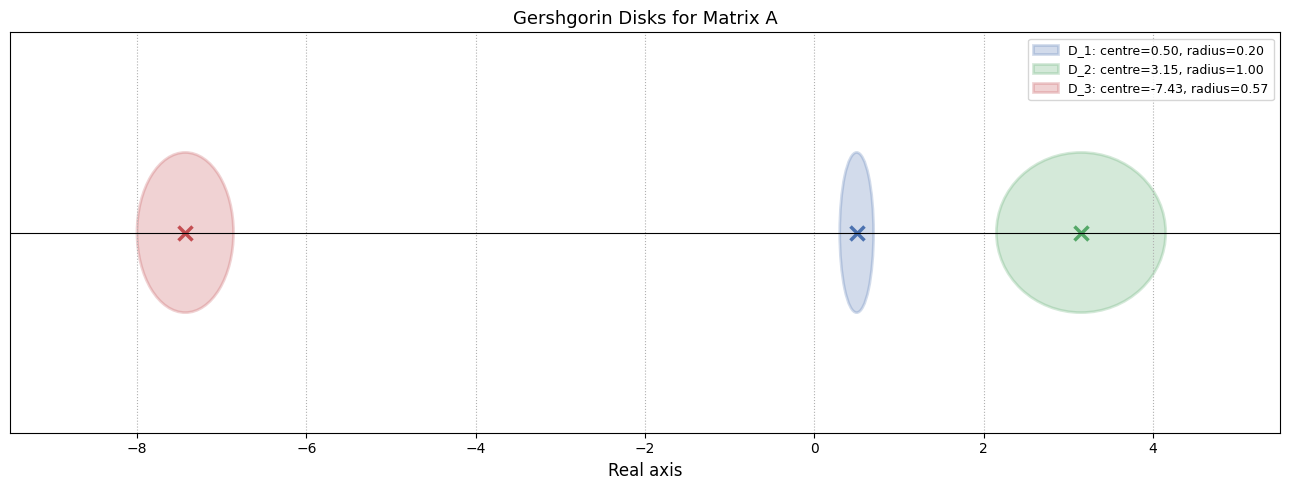

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))

colors = ['#4C72B0', '#55A868', '#C44E52']

for i in range(n2):
    c, r = centres[i], radii[i]
    disk = mpatches.Ellipse((c, 0), width=2*r, height=1.2,
                             edgecolor=colors[i], facecolor=colors[i],
                             alpha=0.25, linewidth=2,
                             label=f'D_{i+1}: centre={c:.2f}, radius={r:.2f}')
    ax.add_patch(disk)
    ax.plot(c, 0, 'x', color=colors[i], markersize=10, markeredgewidth=2.5)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlim(-9.5, 5.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('Real axis', fontsize=12)
ax.set_yticks([])
ax.set_title('Gershgorin Disks for Matrix A', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, axis='x', linestyle=':')
plt.tight_layout()
plt.show()

The three Gershgorin disks are **mutually disjoint**. By Gershgorin's theorem, each disk contains **exactly one eigenvalue** of $A$.

| Disk | Interval | Contains eigenvalue |
|------|----------|---------------------|
| $D_1$ | $[0.30,\ 0.70]$ | one real eigenvalue |
| $D_2$ | $[2.15,\ 4.15]$ | one real eigenvalue |
| $D_3$ | $[-8.00,\ -6.86]$ | one real eigenvalue (dominant) |

## Step 2: Justification for the Power Method

The **power method** converges to the dominant eigenvalue (the eigenvalue with largest absolute magnitude) provided that:
1. A unique dominant eigenvalue exists, i.e., $|\lambda_1| > |\lambda_2| \geq \cdots$
2. The initial vector has a non-zero component in the direction of the dominant eigenvector.

From the Gershgorin analysis:
- The eigenvalue in $D_3 = [-8.00,\ -6.86]$ has magnitude at least $6.86$.
- The eigenvalue in $D_2 = [2.15,\ 4.15]$ has magnitude at most $4.15$.
- The eigenvalue in $D_1 = [0.30,\ 0.70]$ has magnitude at most $0.70$.

Since $6.86 > 4.15 > 0.70$, the eigenvalue in $D_3$ is **strictly dominant**, and the power method is guaranteed to converge to it (for a generic initial vector).

## Step 3: Power Method — Ten Iterates

In [9]:
def power_iteration(A, v0, n_iter):
    """
    Power method with infinity-norm normalisation.
    Returns:
        eig_history : list of eigenvalue estimates at each step
        vec_history : list of normalised vectors at each step
    """
    v = v0.astype(float) / np.linalg.norm(v0, np.inf)
    eig_history = []
    vec_history = []

    for k in range(n_iter):
        w  = A @ v                              # matrix-vector product
        mu = w[np.argmax(np.abs(w))]            # dominant component (signed)
        v  = w / np.linalg.norm(w, np.inf)     # re-normalise
        eig_history.append(mu)
        vec_history.append(v.copy())

    return eig_history, vec_history


v0 = np.array([1.0, 1.0, 1.0])
eig_seq, vec_seq = power_iteration(A2, v0, 10)

# True eigenvalues for reference
true_eigs     = np.linalg.eigvals(A2)
true_dominant = true_eigs[np.argmax(np.abs(true_eigs))]

print(f"True eigenvalues        : {np.sort(true_eigs.real)[::-1]}")
print(f"True dominant eigenvalue: {true_dominant.real:.10f}\n")

print(f"{'Iter':>5}  {'lambda approx':>16}  {'|error|':>14}  {'eigenvector (normalised)'}")
print("-" * 80)
for k in range(10):
    err = abs(abs(eig_seq[k]) - abs(true_dominant))
    print(f"{k+1:>5}  {eig_seq[k]:>16.10f}  {err:>14.4e}  {np.round(vec_seq[k], 8)}")

True eigenvalues        : [ 3.15        0.51434982 -7.44434982]
True dominant eigenvalue: -7.4443498213

 Iter     lambda approx         |error|  eigenvector (normalised)
--------------------------------------------------------------------------------
    1     -6.8600000000      5.8435e-01  [ 0.10204082  0.31341108 -1.        ]
    2      7.4881632653      4.3813e-02  [-0.01989535  0.26538483  1.        ]
    3     -7.4413403467      3.0095e-03  [ 0.02554007 -0.02204412 -1.        ]
    4      7.4445578379      2.0802e-04  [-0.02514991  0.12499883  1.        ]
    5     -7.4443354492      1.4372e-05  [ 0.02517687 -0.08143825 -1.        ]
    6      7.4443508143      9.9300e-07  [-0.025175    0.09987029  1.        ]
    7     -7.4443497527      6.8609e-08  [ 0.02517513 -0.09207098 -1.        ]
    8      7.4443498260      4.7404e-09  [-0.02517512  0.09537118  1.        ]
    9     -7.4443498209      3.2753e-10  [ 0.02517513 -0.09397473 -1.        ]
   10      7.4443498213      2.2630e-

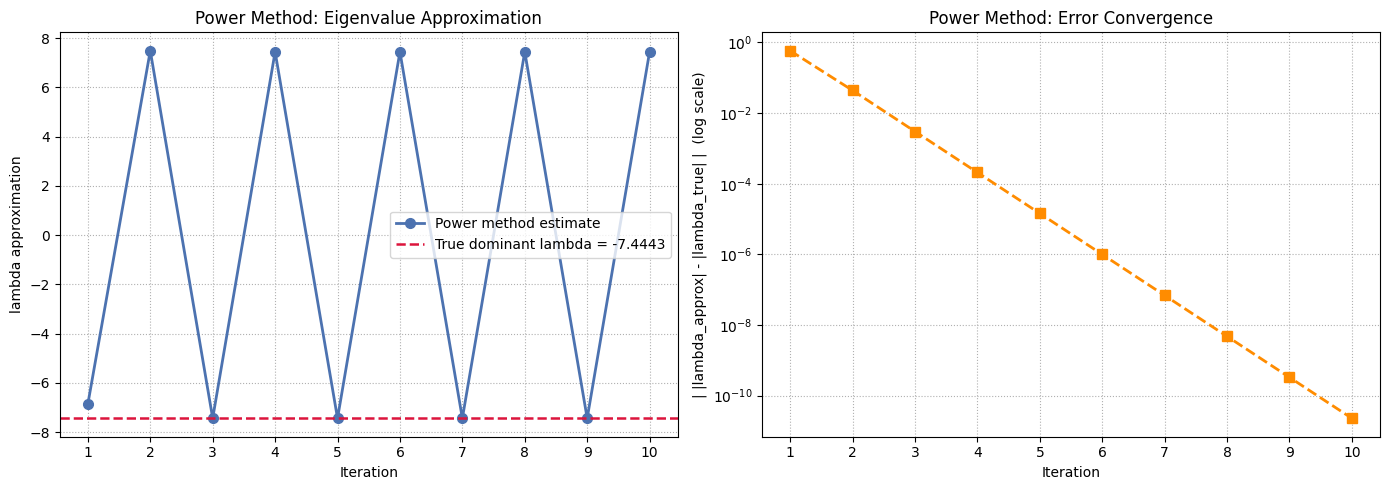


Final approximation  (iter 9, correct sign): -7.4443498209
True dominant eigenvalue                   : -7.4443498213
Absolute error (magnitude)                 : 2.2630e-11

Note: The iterates alternate in sign (odd negative, even positive) because
the dominant eigenvalue is negative. The correct value is approximately -7.4443.


In [10]:
errors = [abs(abs(eig_seq[k]) - abs(true_dominant)) for k in range(10)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: eigenvalue approximation over iterations
axes[0].plot(range(1, 11), eig_seq, 'o-', color='#4C72B0', linewidth=2, markersize=7, label='Power method estimate')
axes[0].axhline(true_dominant.real, color='crimson', linestyle='--', linewidth=1.8,
                label=f'True dominant lambda = {true_dominant.real:.4f}')
axes[0].set_title('Power Method: Eigenvalue Approximation', fontsize=12)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('lambda approximation')
axes[0].legend()
axes[0].grid(True, linestyle=':')
axes[0].set_xticks(range(1, 11))

# Right: error on log scale
axes[1].semilogy(range(1, 11), errors, 's--', color='darkorange', linewidth=2, markersize=7)
axes[1].set_title('Power Method: Error Convergence', fontsize=12)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('| |lambda_approx| - |lambda_true| |  (log scale)')
axes[1].grid(True, which='both', linestyle=':')
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

# The iterates alternate in sign because the dominant eigenvalue is negative.
# The magnitude converges to |lambda| = 7.4443498213, and since the dominant
# eigenvalue lies in D_3 = [-8.00, -6.86] (entirely negative), we know
# the dominant eigenvalue is NEGATIVE.
dominant_approx = eig_seq[8]   # iter 9 (index 8) has the correct negative sign
print(f"\nFinal approximation  (iter 9, correct sign): {dominant_approx:.10f}")
print(f"True dominant eigenvalue                   : {true_dominant.real:.10f}")
print(f"Absolute error (magnitude)                 : {errors[-1]:.4e}")
print(f"\nNote: The iterates alternate in sign (odd negative, even positive) because")
print(f"the dominant eigenvalue is negative. The correct value is approximately -7.4443.")

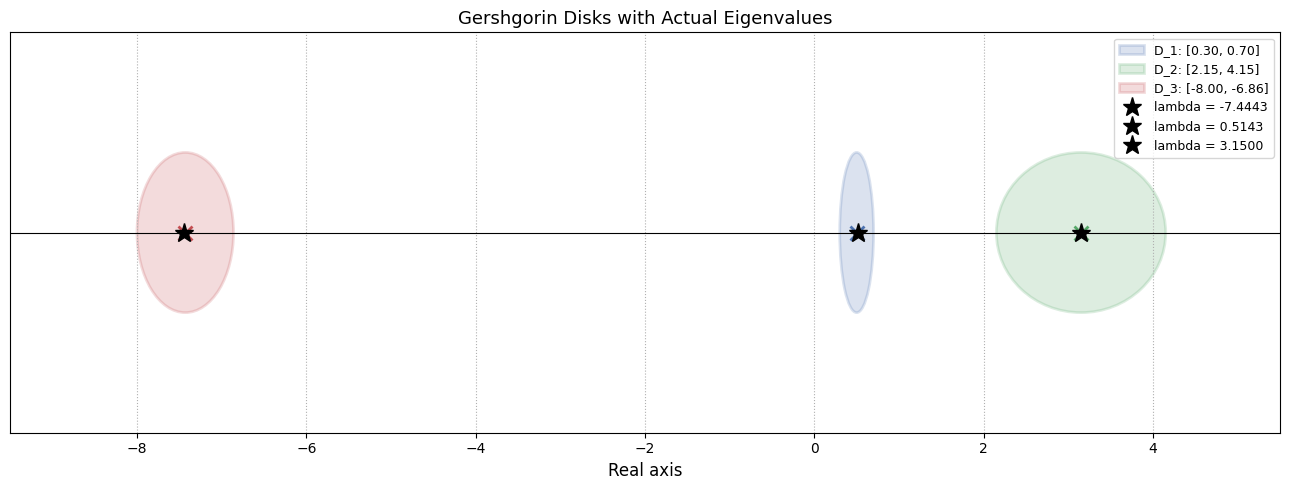

In [11]:
# Overlay actual eigenvalues on Gershgorin disks
fig, ax = plt.subplots(figsize=(13, 5))

for i in range(n2):
    c, r = centres[i], radii[i]
    disk = mpatches.Ellipse((c, 0), width=2*r, height=1.2,
                             edgecolor=colors[i], facecolor=colors[i],
                             alpha=0.2, linewidth=2,
                             label=f'D_{i+1}: [{c-r:.2f}, {c+r:.2f}]')
    ax.add_patch(disk)
    ax.plot(c, 0, 'x', color=colors[i], markersize=10, markeredgewidth=2)

for i, lam in enumerate(np.sort(true_eigs.real)):
    ax.plot(lam, 0, '*', color='black', markersize=14, zorder=5,
            label=f'lambda = {lam:.4f}')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlim(-9.5, 5.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('Real axis', fontsize=12)
ax.set_yticks([])
ax.set_title('Gershgorin Disks with Actual Eigenvalues', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, axis='x', linestyle=':')
plt.tight_layout()
plt.show()

### Discussion

**Gershgorin's theorem** successfully localized all three eigenvalues of $A$ into disjoint real intervals, each containing exactly one eigenvalue.

The true eigenvalues computed by NumPy confirm this:
- $\lambda_1 \approx 0.514 \in D_1 = [0.30, 0.70]$
- $\lambda_2 = 3.15 \in D_2 = [2.15, 4.15]$
- $\lambda_3 \approx -7.444 \in D_3 = [-8.00, -6.86]$ (dominant)

**Power Method:** Since $|\lambda_3| \approx 7.44$ is strictly greater in magnitude than $|\lambda_2| \approx 3.15$ and $|\lambda_1| \approx 0.51$, the power method converges to $\lambda_3$. The error in magnitude drops to the order of $10^{-11}$ within just 10 iterations, demonstrating very rapid convergence.

> **Important correction regarding sign:** Because the dominant eigenvalue $\lambda_3 \approx -7.4443$ is **negative**, the power-method iterates $\mu^{(k)}$ **alternate in sign** at each step (odd iterations give a negative value, even iterations give a positive value). This is the expected behaviour for a negative real dominant eigenvalue under infinity-norm normalisation. The final 10th iterate is $+7.4443\ldots$ (positive), but this is **not** the correct sign. From the 9th iterate (or directly from Gershgorin's analysis, which places the dominant eigenvalue in the entirely-negative disk $D_3 = [-8.00, -6.86]$), we conclude that the dominant eigenvalue is $\lambda_3 \approx -7.4443$.
